# Lecture 08b: Intro to Visualization with Static Plots

Plots, figures, charts, graphs are terms used interchangeably.

## 1. Informative and beautiful plots.
* Know your data and the proper graphs. [Awesome guide!](https://www.data-to-viz.com/)
Select the right graph for the task.

* Aspect ratio = "width-to-height" ratio of plot size. Used to inform and to mislead.
16:9 is the standard in video.
In plots, it can be 5:4, 4:3, and usually is 16:10 so in pixels it is 800 width/500 height.
Not the same for all devices, depending on screen size (mobile VS Desktop VS Laptops).

* Plot size (in absolute pixels) affects speed (similar to images).

* Scale of axes matters as well.
Remember: The shadow is not the same as the phenomenon (Plato's cave and butterflies on the wall).

* Understand how to maximize the ["data-ink ratio"](https://www.darkhorseanalytics.com/blog/data-looks-better-naked), always ["declutter".](https://www.data-to-viz.com/caveat/declutter.html)

* Understand the ["proportional ink" principle.](https://clauswilke.com/dataviz/proportional-ink.html)

* Usefool online [book.](https://clauswilke.com/dataviz/)

* Data management, cleaning before/while plotting.

* Chose the significant dimensions (features) to display. More dimensions is not necessarily better.

* Colours [matter a lot!](https://blog.datawrapper.de/colors/) Printed paper "color spaces" are different from monitor ones.
[954 most used colors on monitors](https://xkcd.com/color/rgb/) and [top 50 in the survey.](https://blog.xkcd.com/2010/05/03/color-survey-results/)
Colours tutorials by: [seaborn,](https://seaborn.pydata.org/tutorial/color_palettes.html) [matplotlib](https://matplotlib.org/3.5.1/tutorials/colors/colors.html)
Color Brewer, a must read for [colours.](https://colorbrewer2.org/#type=sequential&scheme=BuGn&n=3)
[RGBA model](https://en.wikipedia.org/wiki/RGBA_color_model) colors.
[Aesthetics](http://seaborn.pydata.org/tutorial/aesthetics.html) matter, colours may be in discord, like Cacofonix.

* Known [plotting caveats](https://www.data-to-viz.com/caveats.html).
Many suboptimal practices [everywhere, even in official docs.](https://matplotlib.org/3.1.0/gallery/showcase/bachelors_degrees_by_gender.html)
Not all problems are related to plots.
[Plots to avoid.](https://genomicsclass.github.io/book/pages/plots_to_avoid.html)

## 2. The limitations of "summary metrics"

* Plots convey meaningful information.
> Exploratory Data Analysis [(EDA)](https://en.wikipedia.org/wiki/Exploratory_data_analysis)
> [Descriptive Stats](https://en.wikipedia.org/wiki/Descriptive_statistics)
> [Inferencial Stats](https://en.wikipedia.org/wiki/Statistical_inference)
> [Predicitive Analytics.](https://en.wikipedia.org/wiki/Predictive_analytics)

* [Anscombe's quartet](https://en.wikipedia.org/wiki/Anscombe%27s_quartet), Try the [example](https://seaborn.pydata.org/examples/anscombes_quartet.html) in seaborn.

## Choosing the Right Plot — A Decision Flowchart

Not sure which chart to use? Start here and follow the arrows.

```mermaid
                        What is your goal?
                             │
          ┌──────────────────┼──────────────────┐
          ▼                  ▼                  ▼
     DISTRIBUTION      RELATIONSHIP         COMPARISON
 (one variable)      (two+ variables)     (across groups)
          │                  │                   │
     ┌────┴────┐         ┌───┴───┐          ┌────┴────┐
     ▼         ▼         ▼       ▼          ▼         ▼
 Continuous Categorical  Both    Both    Few groups  Many groups
     │         │      continuous  mixed       │         │
     ▼         ▼          │        │          ▼         ▼
 Histogram  Bar chart     ▼        ▼       Bar chart  Heatmap
 KDE plot   Pie chart  Scatter  Strip       Box plot
 Box plot   (avoid!)    plot    plot        Violin
 Violin                  │                    │
                         ▼                    ▼
                    Add dimensions:       Add dimensions:
                    color = groups        hue = sub-groups
                    size = magnitude      facets = panels
                    facets = panels
```

### Quick reference table

| Your data | Your question | Recommended plot |
|---|---|---|
| 1 numeric variable | What's the distribution? | Histogram, KDE, box plot |
| 1 categorical variable | How many in each category? | Bar chart (NOT pie chart) |
| 2 numeric variables | How are they related? | Scatter plot |
| 1 numeric + 1 categorical | How does the distribution differ? | Box plot, violin plot, strip plot |
| Many numeric variables | What are all the relationships? | Pair plot, correlation heatmap |
| Hierarchical / part-of-whole | What are the proportions? | Treemap, sunburst |
| Geographic data | Where are values located? | Choropleth map |
| Time series | How does it change over time? | Line chart |

### Common mistakes to avoid
- **Pie charts**: Hard to compare slices — use bar charts instead.
- **3D charts**: Almost always harder to read than 2D — avoid unless truly 3D data.
- **Dual y-axes**: Can be misleading — use facets or separate plots.
- **Too many colors**: Humans can distinguish ~7 categories — group the rest as "Other".

See also: [From Data to Viz](https://www.data-to-viz.com/) — an interactive decision tree for plots.

In [1]:
# Using the terminal, activate venv and install the following packages:
# python -m pip install seaborn matplotlib

In [2]:
# Always import the necessary modules at the first part of the code

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set_theme(style="ticks")

# Load the example dataset for Anscombe's quartet from seaborn.
df = sns.load_dataset("anscombe")
df.sample(6)

,dataset,x,y
20,II,7.0,7.26
41,IV,8.0,5.56
1,I,8.0,6.95
14,II,9.0,8.77
25,III,9.0,7.11
36,IV,8.0,8.84


In [4]:
len(df)

44

In [5]:
df.groupby("dataset").sum()

,x,y
dataset,,
I,99.0,82.51
II,99.0,82.51
III,99.0,82.50
IV,99.0,82.51


In [6]:
df.groupby("dataset").describe()

x                                               y            \
        count mean       std  min  25%  50%   75%   max count      mean   
dataset                                                                   
I        11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
II       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV       11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                   
              std   min    25%   50%   75%    max  
dataset                                            
I        2.031568  4.26  6.315  7.58  8.57  10.84  
II       2.031657  3.10  6.695  8.14  8.95   9.26  
III      2.030424  5.39  6.250  7.11  7.98  12.74  
IV       2.030579  5.25  6.170  7.04  8.19  12.50

In [7]:
df['observation'] = df.groupby('dataset')['dataset'].cumcount()

pivot_df = (
    df.set_index(['observation','dataset'])
            .stack().unstack([1,2])
            .rename_axis(None)
            .rename_axis(('dataset','observation'), axis=1)
           )  # Use paseaborn marenthesis for line breaks and commenting out arguments.

            
pivot_df  #The x values are the same for the first three datasets

dataset         I           II         III           IV       
observation     x      y     x     y     x      y     x      y
0            10.0   8.04  10.0  9.14  10.0   7.46   8.0   6.58
1             8.0   6.95   8.0  8.14   8.0   6.77   8.0   5.76
2            13.0   7.58  13.0  8.74  13.0  12.74   8.0   7.71
3             9.0   8.81   9.0  8.77   9.0   7.11   8.0   8.84
4            11.0   8.33  11.0  9.26  11.0   7.81   8.0   8.47
5            14.0   9.96  14.0  8.10  14.0   8.84   8.0   7.04
6             6.0   7.24   6.0  6.13   6.0   6.08   8.0   5.25
7             4.0   4.26   4.0  3.10   4.0   5.39  19.0  12.50
8            12.0  10.84  12.0  9.13  12.0   8.15   8.0   5.56
9             7.0   4.82   7.0  7.26   7.0   6.42   8.0   7.91
10            5.0   5.68   5.0  4.74   5.0   5.73   8.0   6.89

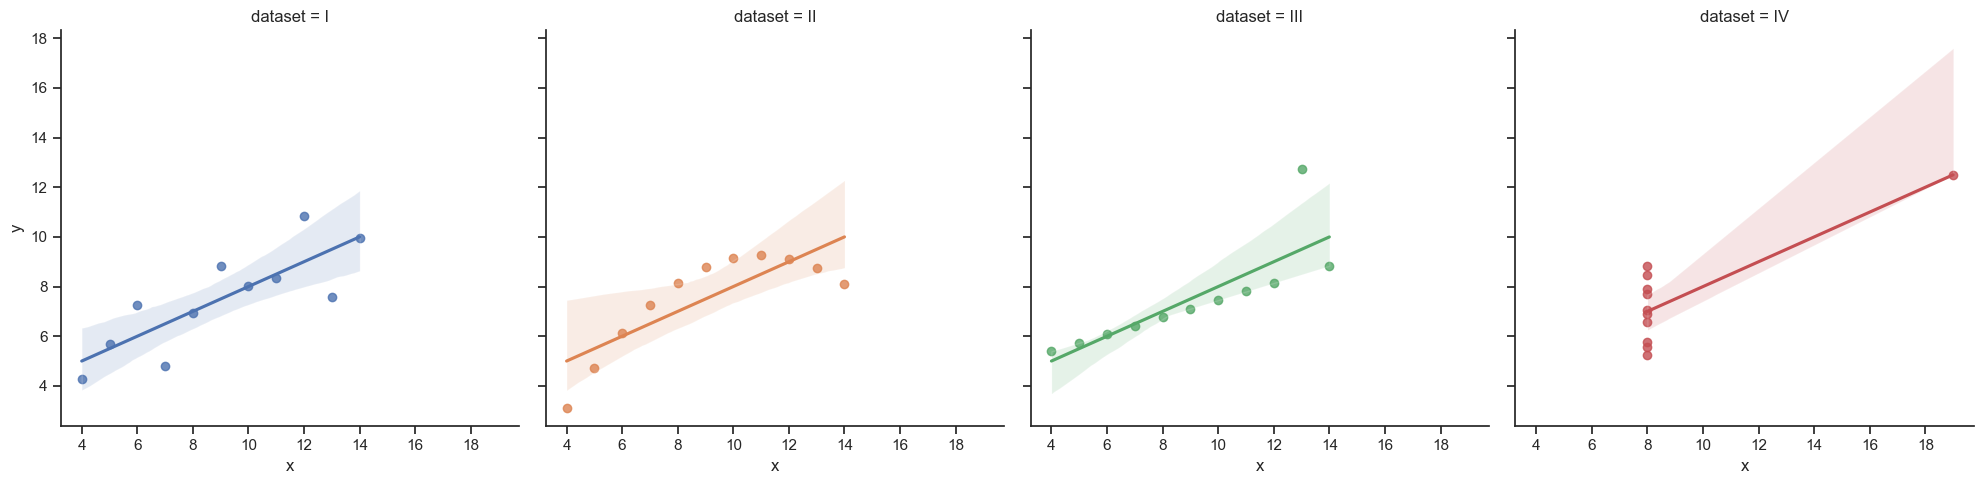

In [8]:
# Show the results of a linear regression model for each dataset.
sns.lmplot(
        df,
        x="x",
        y="y",
        col="dataset",
        hue="dataset"
          );


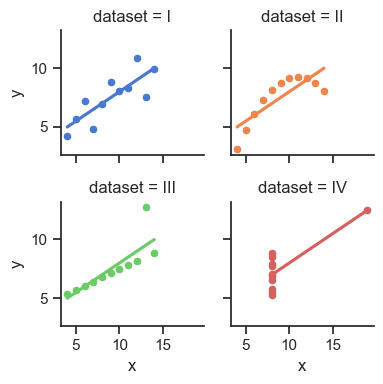

In [9]:
# Some aesthetic customizations
sns.lmplot(
    data=df,
    x="x",
    y="y",
    col="dataset",
    col_wrap=2, 
    hue="dataset",
    palette="muted",
    ci=None,
    height=2,
    scatter_kws={"s": 20, "alpha": 1});

In [10]:
# sns.lmplot?

## 3. The python visualization ecosystem

* The python [visualization ecosystem](https://pyviz.org/) is huge and growing fast.    
* Matplotlib is the high level API most advanced python libraries use.

* [Plots](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html) VS [table visualization](https://pandas.pydata.org/pandas-docs/stable/user_guide/style.html#Table-Visualization).     
plt.style.use("cyberpunk
* Plotting with [pandas](https://pandas.pydata.org/docs/user_guide/visualization.html), [matplotlib](https://matplotlib.org/), [seaborn](https://seaborn.pydata.org/).  

* Ready-made styling libraries examples:   
[dufte](https://github.com/nschloe/dufte),   
[cyberpunk](https://github.com/dhaitz/mplcyberpunk),   
[science plo    palette="cubehelix"ts](https://github.com/garrettj403/SciencePlots)

* Ready-made Web Apps Visualization libraries: See dedicated notebook
    * Streamlit
    * Taipy
    * Voila

* Auto-EDA or low code: See dedicated notebook
    * PyGwalker
    * McKinsey `Vizro` (https://github.com/mckinsey/vizro)
      

* Syntax:  
library.function(arguments)  
df.function(arguments)  
figure.function(arguments)  
figure_object.function(arguments)

### Most difficult issues in ploting:  
* Parameter names.  
* Different modules and plots have different syntax, different function names, diffent goals.  
* Order of methods and parameters matters a lot, because the last settings override other previous settings.  
* Common parameter names are used by the specific figure object, or by the "high level" API library, or by both, but may need different datatypes as inputs. Imhv, the most confusing, error-prone issue.

## 4. Heart Disease Dataset. Import necessary modules and data

### Read dataset file as dataframe

In [ ]:
# My relative path.
# df = pd.read_csv(* Syntax:  
library.function(arguments)  
df.function(arguments)  
figure.function(arguments)  
figure_object.function(arguments)
#    "./../../data/predict_heart_disease_train.csv",  # this is the path in which I have my file.
# )

# df.head()

In [12]:
df = pd.read_csv("predict_heart_disease_train.csv")

In [13]:
# View first data row and column with label "Heart Disease".
# https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
df.loc[0, "Heart Disease"]  # This is the recommended method. 
# Same result with the syntax below:
# df.iloc[0]["Heart Disease"]  
# df.iloc[0][14]

'Presence'

## 5. Intro to plotting with seaborn

### Countplot

[countplot function and examples](https://seaborn.pydata.org/generated/seaborn.countplot.html?highlight=countplot#seaborn.countplot)

In [14]:
df.head(5)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [15]:
# sns.countplot?  # Uncomment to read the countplot parameters.

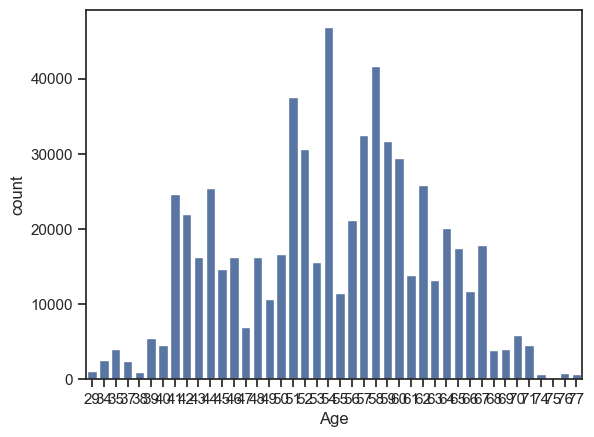

In [ ]:
# Default seaborn output with two arguments; unsorted, confusing, labels overlapping.
sns.countplot(
    data=df,
    x="Age", * Syntax:  
library.function(arguments)  
df.function(arguments)  
figure.function(arguments)  
figure_object.function(arguments)

### Change order of x-axis

In [17]:
# The plot by default takes the order of appearance of each value in the data.
df.Age.unique()

array([58, 52, 56, 44, 38, 59, 60, 48, 41, 42, 53, 50, 65, 46, 62, 57, 54,
       66, 51, 55, 43, 71, 63, 61, 35, 49, 47, 67, 64, 45, 40, 70, 69, 37,
       76, 34, 68, 39, 74, 77, 29, 75])

In [18]:
# This is an array, we need to convert it to a list.
type(df.Age.unique())

numpy.ndarray

In [19]:
# Create a list to use as argument.
sorted_age = df.Age.unique().tolist()

# Sort the list.
sorted_age = sorted(sorted_age)
sorted_age

[29,
 34,
 35,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 74,
 75,
 76,
 77]

### Assign a name to the plot. This is useful for parameterization.

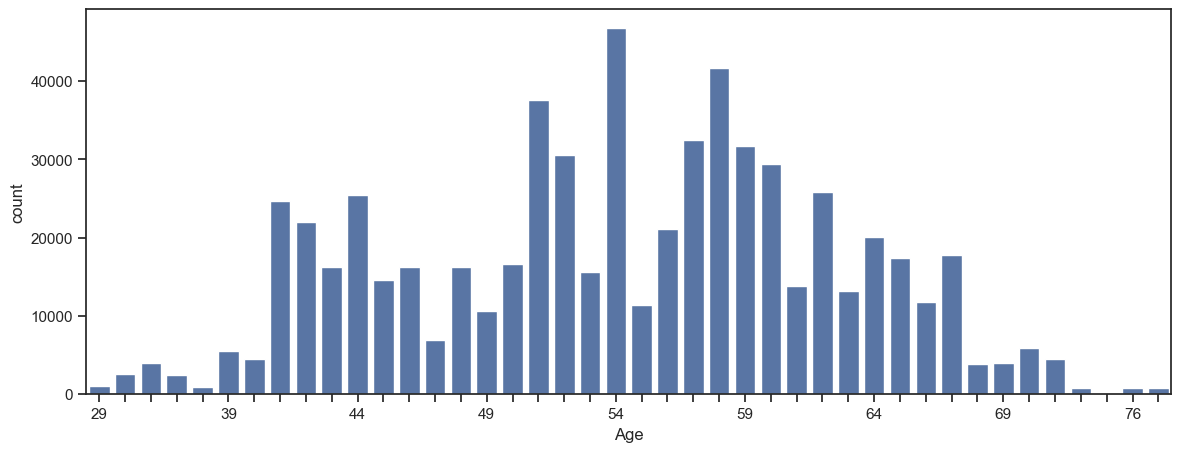

In [20]:
# Set the order of x-axis values:
# parameter of function is: order
# argument value of parameter is: sorted_age and should be of type list
plt.figure(figsize=(14, 5))

sorted_by_age_plot = sns.countplot(
    data=df,
    x="Age",
    order=sorted_age
);

# Show only every 5th tick label to avoid overlap
for i, label in enumerate(sorted_by_age_plot.get_xticklabels()):
    if i % 5 != 0:
        label.set_visible(False)

### Rotate x tick labels

/tmp/ipykernel_46247/1499380164.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  by_age_plot = sns.countplot(
/tmp/ipykernel_46247/1499380164.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  by_age_plot.set_xticklabels(


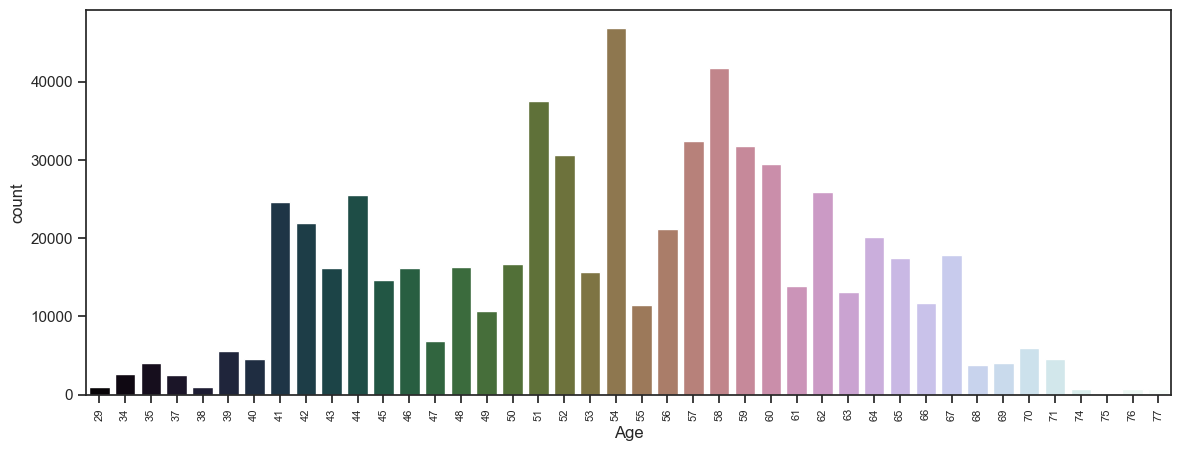

In [ ]:
# use a name to assign new arguments to parameters, to modify the default ones.
plt.figure(figsize=(14, 5))

by_age_plot = sns.countplot(
    x="Age", 
    data=df, 
    order=sorted_age, 
    palette="cubehelix"
);

by_age_plot.set_xticklabels(
    by_age_plot.get_xticklabels(), 
    rotation=90, 
    horizontalalignment='center',
    fontsize=8
);

### Remove axes lines and modify axes labels

/tmp/ipykernel_46247/1002148085.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  by_age_plot.set_xticklabels(


<Figure size 640x480 with 0 Axes>

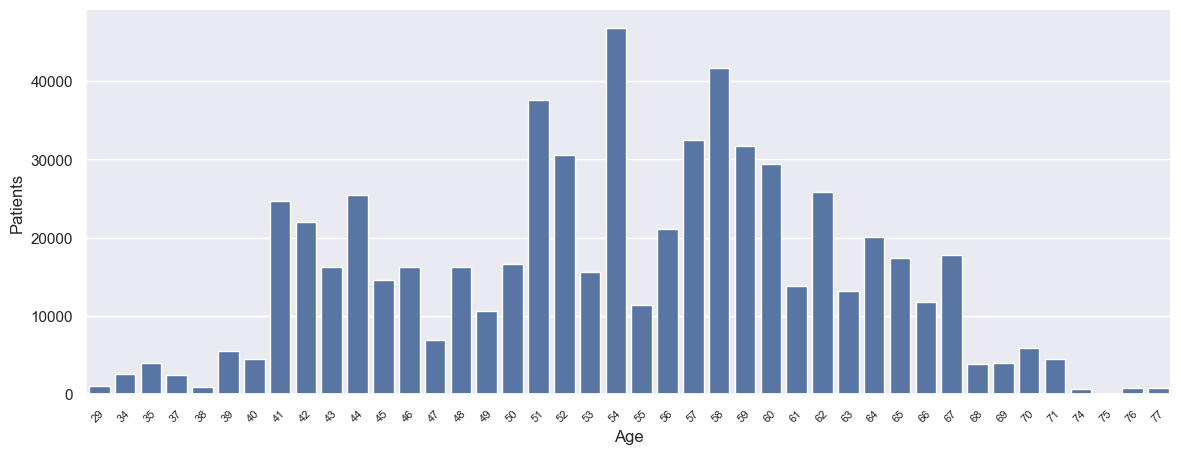

In [38]:
# remove frame lines around the plot.
sns.despine(bottom=True, left=True)  

plt.figure(figsize=(14, 5))

by_age_plot = sns.countplot(
    x="Age", 
    data=df, 
    order=sorted_age
);  # argument is a list

by_age_plot.set_xticklabels(
    by_age_plot.get_xticklabels(),
    rotation=45, 
    horizontalalignment='right',
    rotation_mode='anchor',  # anchor rotation at the alignment point so labels align with ticks
    fontsize=8
);

# top and right are removed by default with despine()

# modify x axis and y axis labels
by_age_plot.set(
    xlabel="Age",
    ylabel="Patients"
);

### Remove ticks

/tmp/ipykernel_46247/1661929330.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  by_age_plot.set_xticklabels(


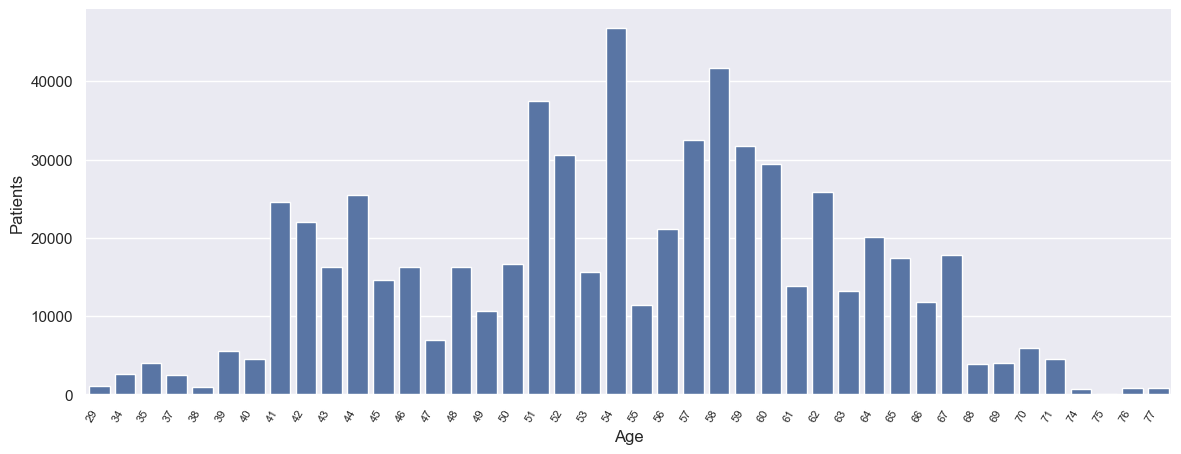

In [39]:
# Remove ticks using seaborn method. "Ticks" is not the same as "tick labels".

plt.figure(figsize=(14, 5))

by_age_plot = sns.countplot(
    x="Age",
    data=df, 
    order=sorted_age
);  # argument is a list

by_age_plot.set_xticklabels(
    by_age_plot.get_xticklabels(), 
    rotation=60, 
    horizontalalignment='right',
    fontsize=8
);

# modify x axis and y axis labels
by_age_plot.set(
    xlabel="Age",
    ylabel="Patients"
);

sns.despine(bottom=True, left=True)

# Be careful: ticks and tick labels are not the same objects.
# seaborn method to remove x and y axis ticks
sns.set_style({'xtick.bottom': False, 'ytick.left': False})

/tmp/ipykernel_46247/4294580839.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  by_age_plot.set_xticklabels(


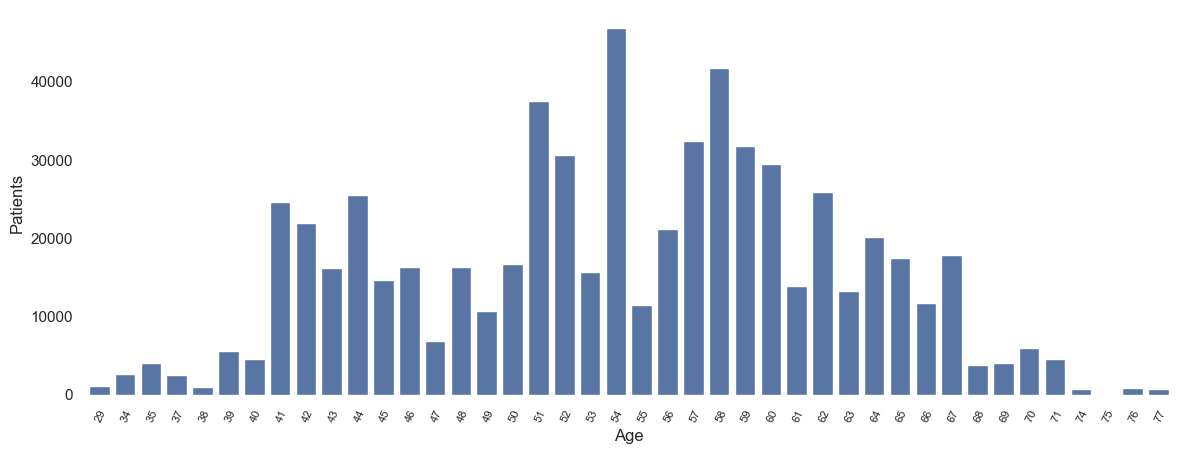

In [24]:
# Remove ticks, alternative matplotlib method that sets new default values.

plt.figure(figsize=(14, 5))

by_age_plot = sns.countplot(
    x="Age",
    data=df,
    order=sorted_age
);  # argument is a list

# Update xtick labels
by_age_plot.set_xticklabels(
    by_age_plot.get_xticklabels(), 
    rotation=65, 
    horizontalalignment='right',
    rotation_mode='anchor',
    fontsize=8
);

# Update axis labels
by_age_plot.set(xlabel="Age", ylabel="Patients");
# by_age_plot.yaxis.set_visible(False)
# by_age_plot.set(xticks=[])

sns.despine(bottom=True, left=True)

# similar matplotlib method to modify x axis ticks.
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # set ticks along the bottom edge to off
    top=False,         # set ticks along the top edge to off
    labelbottom=True   # show ticks labels at the bottom 
)

### Configure figure size, background, colour. Which lines do the trick?

In [25]:
# Show which is palette seaborn uses by default.
sns.color_palette()

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

/tmp/ipykernel_46247/3280010001.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  by_age_plot = sns.countplot(
/tmp/ipykernel_46247/3280010001.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  by_age_plot.set_xticklabels(
/tmp/ipykernel_46247/3280010001.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  by_age_plot.set_yticklabels(


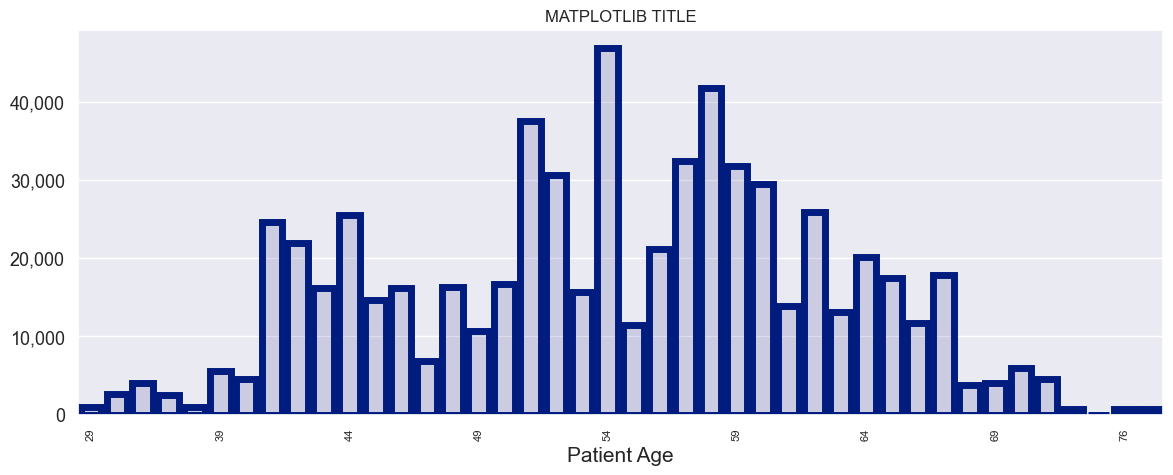

In [40]:
# ignore the warning for the class. Understand the warning for the future

plt.figure(figsize=(14, 5));

sns.set_style(
    "darkgrid",
    {'xtick.bottom': False, 'ytick.left': False}
);


sns.despine(bottom=True, left=True);

# Create plot object
by_age_plot = sns.countplot(
    x="Age",
    data=df,
    order=sorted_age,
    facecolor=(0.10, 0.10, 0.5, 0.15),  # RGBA combination codes (Red, Green, Blue. Opaqueness is the opposite of transparency)
    palette="muted",
    linewidth=5,
    edgecolor=sns.color_palette("dark", len(sorted_age))
);

# set title using seaborn
by_age_plot.set_title("SEABORN TITLE")

# set title using matplotib. The last setting is used in the plot. The previous is overwritten
plt.title("MATPLOTLIB TITLE")

by_age_plot.set_xticklabels(
    by_age_plot.get_xticklabels(),
    rotation=90,
    horizontalalignment='center',
    size=8
);

# Show only every 5th tick label to avoid overlap
for i, label in enumerate(by_age_plot.get_xticklabels()):
    if i % 5 != 0:
        label.set_visible(False)

by_age_plot.set_yticklabels(
    by_age_plot.get_yticks(), 
    size=13, rotation=0
); # ignore the warning for now
# by_age_plot.set_yticklabels(by_age_plot.get_yticks(),size=12);

# Put import always at start of code, here only for this lecture.
from matplotlib.ticker import StrMethodFormatter 
# No decimal places, use comma to separate thousands
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 

# modify x axis and y axis labels
# by_age_plot.set(xlabel="Age", ylabel="Patients");
by_age_plot.set_xlabel(
    xlabel="Patient Age",
    fontsize=15,
    rotation=0
);

by_age_plot.set_ylabel(
    ylabel="",
    fontsize=20); #rotation=0

### In class exercise, do it in 5 minutes (only for hackers).
Change color pallette to countplot. 
**Hint:** the correct method is to "google" it.

### Histplot. Read docstring "Notes".
* bins: range, width.   
Did you notice that the bins in data and in above graphs above are of unequal length?  
[histplot function parameters and examples](https://seaborn.pydata.org/generated/seaborn.histplot.html)

In [27]:
# sns.histplot?

In [41]:
## Select a subset for faster plot for the lecture.
presence_df = df[df["Heart Disease"] == "Presence"]

In [42]:
presence_df.Cholesterol.describe()  
# presence_df["Cholesterol"].describe()

count    282454.000000
mean        248.103585
std          32.922645
min         126.000000
25%         226.000000
50%         246.000000
75%         269.000000
max         564.000000
Name: Cholesterol, dtype: float64

In [43]:
presence_df.head(3)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
5,5,38,1,4,138,283,0,0,147,1,1.6,2,2,7,Presence


In [44]:
presence_df.sort_values("Cholesterol").head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
487103,487103,45,1,4,120,126,0,2,105,0,0.0,1,1,7,Presence
425396,425396,52,1,4,120,130,0,2,111,0,2.0,2,3,3,Presence
55374,55374,58,1,4,130,149,0,2,126,1,3.8,2,3,7,Presence
130387,130387,64,1,4,150,149,0,2,109,0,1.6,2,0,7,Presence
438433,438433,41,1,4,140,149,0,2,132,1,0.0,1,0,7,Presence


### Default output.

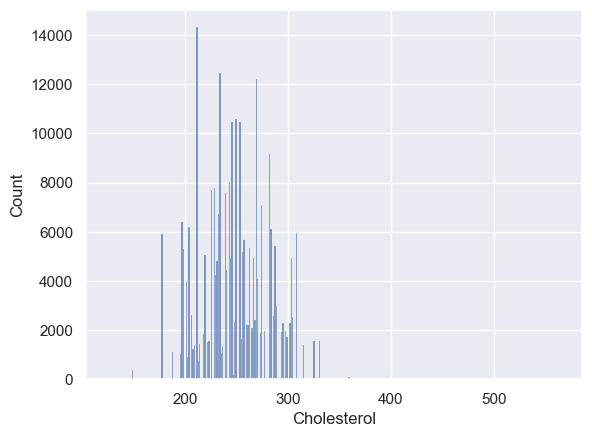

In [49]:
# Default output may be ugly because the bby_age_plot.in range defaults to extremes and data may have extreme values.
sns.histplot(
    presence_df,
    x="Cholesterol",
    
);

### Modify x axis values range.

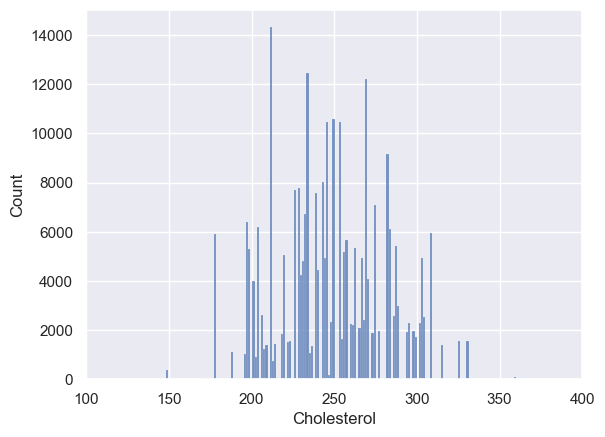

In [50]:
# show only from 100 to 400.
sns.histplot(x="Cholesterol", data=presence_df)

plt.xlim(100, 400);

### Modify size, binwidth, color, edgecolor, edge line, labels.

In [51]:
# show seaborn style
# sns.axes_style?
sns.axes_style()

{'axes.facecolor': '#EAEAF2',
 'axes.edgecolor': 'white',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': 'white',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

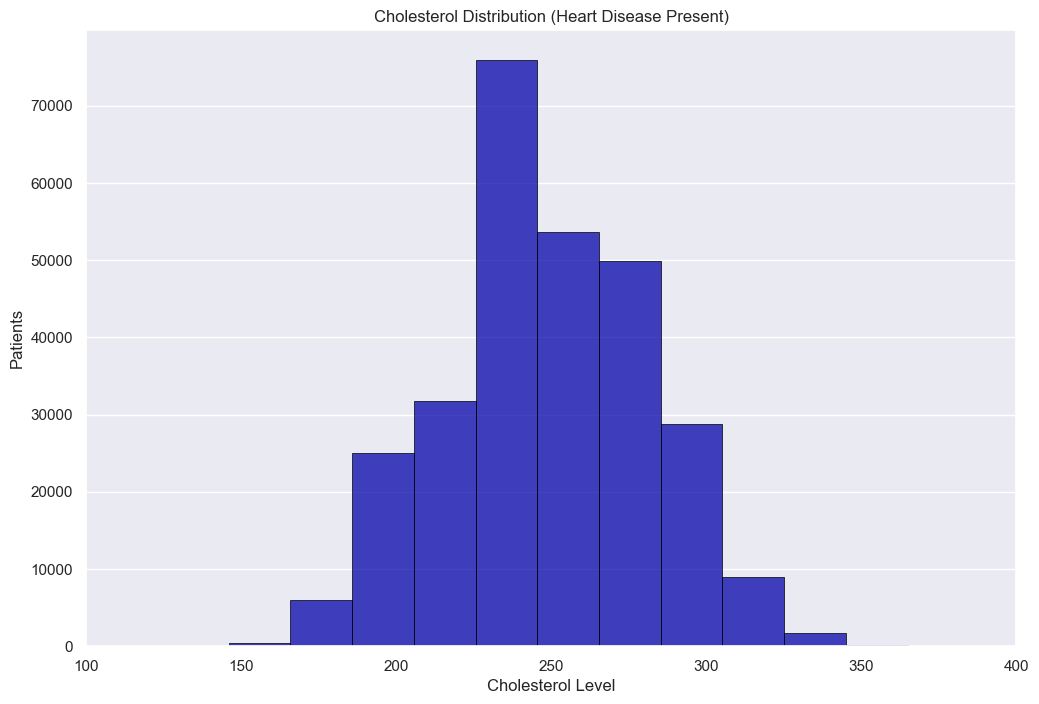

In [35]:
### syntax without naming the plot => chain syntax
# Show only from 100 to 400 and set binwidth as 20.
plt.figure(figsize=(12,8))

sns.set_style("darkgrid", {'xtick.bottom': False, 'ytick.left': False})

sns.histplot(
    x="Cholesterol", 
    data=presence_df, 
    binwidth=20,
    color='#0504AA',
    edgecolor="black",
    linewidth=0.5
).set(xlabel="Cholesterol Level", ylabel="Patients");

plt.xlim(100, 400);

# hide horizontal grid lines
plt.grid(visible=False, axis="x")  # https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.pyplot.grid.html

plt.title("Cholesterol Distribution (Heart Disease Present)");  # I used the matplotlib method  

# Uncomment a line below to save the figure.
# plt.savefig("cholesterol_histplot.jpg")
# plt.savefig("cholesterol_histplot.png")  # Output format matters.

### In class exercise, do it in 5 minutes (only for hackers).
Add to the histplot:  
* a) a title and    
* b) a legend.  

**Hint:** The correct method is to "google it".  
**Hint 2:** Do one thing at a time.

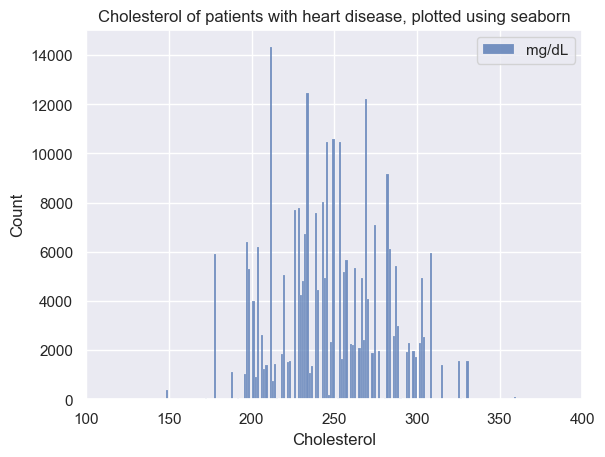

In [52]:
sns.histplot(
    data=presence_df,
    x="Cholesterol",
    label="mg/dL"
).set_title('Cholesterol of patients with heart disease, plotted using seaborn')  # I used the seaborn method

plt.legend()

plt.xlim(100, 400);

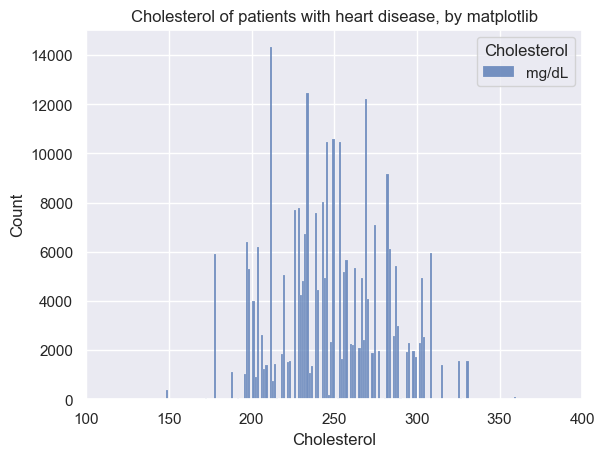

In [ ]:
sns.histplot(x="Cholesterol", data=presence_df)
plt.titldata=presence_df,e('Cholesterol of patients with heart disease, by matplotlib')  # I used matplotlib method for title.
plt.legend(title='Cholesterol', loc='upper right', labels=['mg/dL'])  # Use matplotlib for legend.
plt.xlim(100, 400);

### Resources for the data set.
[Heart Disease dataset on Kaggle](https://www.kaggle.com/datasets/rashadrmammadov/heart-disease-prediction)

[UCI Machine Learning Repository - Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease)

## 6. Assignment:  Use the Matplotlib tutorial to create two subplots, by degree and gender, based on the % of women in 2011.

 
 
[Link to old docs, bachelor degrees by gender](https://matplotlib.org/3.1.0/gallery/showcase/bachelors_degrees_by_gender.html)  

First plot: All degrees where women are >50%.  
Second plot: All degrees where women are <=50%.    
Grades: minus two points (-2) for anyone that does it. 

This is the old link that goes to a new example: [Bachelor degrees by gender => stock prices](https://matplotlib.org/stable/gallery/showcase/bachelors_degrees_by_gender.html?highlight=degree%20gender)   
Conclusion: "Everything changes".


<u>Hints:</u>  
Write pseudocode first.  
Combine pandas and matplotlib.  
Use pandas to read the file as dataframe.  
 
Filter year 2011 according to the conditions to find the columns.  
Split the data in two dataframes using columns.  
Plot using the proper method.

### Extra: The ugliest plots online, guess [by who.](https://www.ggb.gr/el/expost_evaluations_ggb_espa_programmes)  Scroll down and open the links.   
